# Entrenamiento de modelo de predicción de puntuación


## Importación de librerias necesarias


In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2


In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


2025-12-27 17:26:47.374823: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-27 17:26:47.387696: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-27 17:26:47.391528: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-27 17:26:47.401305: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-27 17:26:49.273498: W tensorflow/compiler/tf2

In [4]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.14 (main, Oct 10 2025, 08:54:04) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: []
❌ No GPU detected


I0000 00:00:1766874414.109705  556744 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-27 17:26:54.155554: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark


:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-8eb7753a-766a-4edb-b69e-044263fcef6e;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 113ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

## Cargar datos fuente de entrenamiento


In [6]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [7]:
REGENERATE_MODEL = True


In [8]:
src_dir_categorical = spark_utils.path(
    'final_training_data_rating_array_categorical', catalog = GOLD_PREMODELING
)

In [9]:
from src.utils.models import CategoricalModel
categorical_model = CategoricalModel(
    'categorical_model', 
    METASTORE_PATH, 
    num_classes=6,
    tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    spark_utils=spark_utils,
    target_path=src_dir_categorical,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)
categorical_model.prepare_data(
    target_columns=[b"rating"], 
    shuffle_buffer_size=-1,
    batch_size=1024,
)

2025-12-27 17:27:03.859743: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


## Crear modelo de predicción


In [10]:
categorical_model.create_model()


<Sequential name=sequential, built=True>

In [11]:
categorical_model.plot_model(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/category_model.png",
    levels = 4
)

{'attributes': {'rankdir': 'LR', 'concentrate': True, 'dpi': 200, 'splines': 'ortho'}, 'name': '', 'type': 'digraph', 'strict': False, 'suppress_disconnected': False, 'simplify': False, 'current_child_sequence': 22, 'nodes': {'node': [{'attributes': {'shape': 'record'}, 'type': 'node', 'parent_graph': <pydot.core.Dot object at 0x7a605deb0690>, 'sequence': 1, 'name': 'node', 'port': None}, {'attributes': {'style': 'filled', 'fillcolor': '#ffffff', 'fontcolor': '#000000', 'fontname': 'Times New Roman', 'fontsize': '12', 'color': '#ffffff', 'penwidth': '1.0'}, 'type': 'node', 'parent_graph': <pydot.core.Dot object at 0x7a605deb0690>, 'sequence': 18, 'name': 'node', 'port': None}], '134554300991632': [{'attributes': {'label': '<<table border="0" cellborder="1" bgcolor="#193169" cellpadding="10"><tr><td colspan="2" bgcolor="#193169"><font point-size="16" color="white"><b>dense</b> (Dense)</font></td></tr><tr><td bgcolor="white"><font point-size="14">Input shape: <b>(None, 400)</b></font></t

'/mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_model.png'

In [ ]:
if REGENERATE_MODEL:
    history_model_categorical = categorical_model.train(epochs=10)


Epoch 1/10
   4170/Unknown 938s 221ms/step - accuracy: 0.6726 - loss: 0.8885

2025-11-16 13:35:54.669693: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.78067, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/categorical_model/model_checkpoints/rating_model_epoch_01.h5


2025-11-16 13:38:40.559242: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1104s 261ms/step - accuracy: 0.6913 - loss: 0.8187 - val_accuracy: 0.6986 - val_loss: 0.7807 - learning_rate: 0.0010
Epoch 2/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7073 - loss: 0.7669
Epoch 2: val_loss improved from 0.78067 to 0.73303, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/categorical_model/model_checkpoints/rating_model_epoch_02.h5


...

4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1075s 257ms/step - accuracy: 0.7458 - loss: 0.6574 - val_accuracy: 0.7633 - val_loss: 0.6201 - learning_rate: 0.0010
Epoch 8/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.7499 - loss: 0.6479
Epoch 8: val_loss improved from 0.62010 to 0.60734, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/categorical_model/model_checkpoints/rating_model_epoch_08.h5


2025-11-16 15:44:09.755387: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1076s 257ms/step - accuracy: 0.7510 - loss: 0.6451 - val_accuracy: 0.7683 - val_loss: 0.6073 - learning_rate: 0.0010
Epoch 9/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.7545 - loss: 0.6359
Epoch 9: val_loss improved from 0.60734 to 0.59114, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/categorical_model/model_checkpoints/rating_model_epoch_09.h5


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1074s 256ms/step - accuracy: 0.7556 - loss: 0.6334 - val_accuracy: 0.7743 - val_loss: 0.5911 - learning_rate: 0.0010
Epoch 10/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.7583 - loss: 0.6258
Epoch 10: val_loss improved from 0.59114 to 0.58222, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/categorical_model/model_checkpoints/rating_model_epoch_10.h5


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1083s 259ms/step - accuracy: 0.7593 - loss: 0.6238 - val_accuracy: 0.7785 - val_loss: 0.5822 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.


2025/11/16 16:20:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/16 16:20:10 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/11/16 16:20:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


70642454865d45c885b358c97a375133
Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_category_categorical_model.png


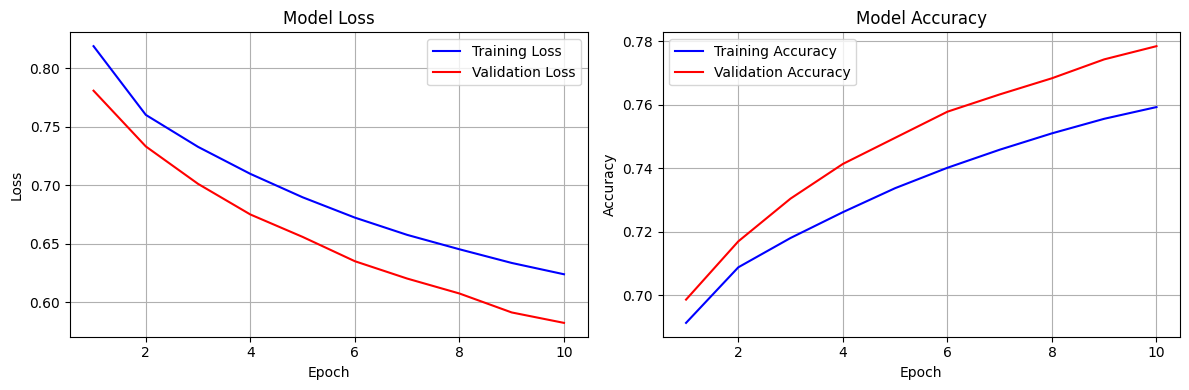

In [ ]:
if REGENERATE_MODEL:
    for name, model in [
        ("categorical_model", categorical_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print(exp)

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_category_{name}.png"
        )


## Cargar modelo


In [12]:
from src.utils.models import CategoricalModel
categorical_model = CategoricalModel(
    'categorical_model', 
    METASTORE_PATH, 
    num_classes=6,
    tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    spark_utils=spark_utils,
    target_path=src_dir_categorical,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)
categorical_model.prepare_data(
    target_columns=[b"rating"], 
    shuffle_buffer_size=-1,
    batch_size=1024,
)
categorical_model.load_latest_model()


/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Calculating predictions on test dataset...


2025-12-27 17:36:40.666336: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Evaluation complete: 534601 samples
y_true shape: (534601, 1), y_pred shape: (534601, 6)
Saved confusion matrix data to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/categorical_model/confusion_matrix_data.npz
Confusion matrix data logged to MLflow run 70642454865d45c885b358c97a375133
Confusion matrix saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/categorical_model/confusion_matrix.png
Confusion matrix logged to MLflow run 70642454865d45c885b358c97a375133


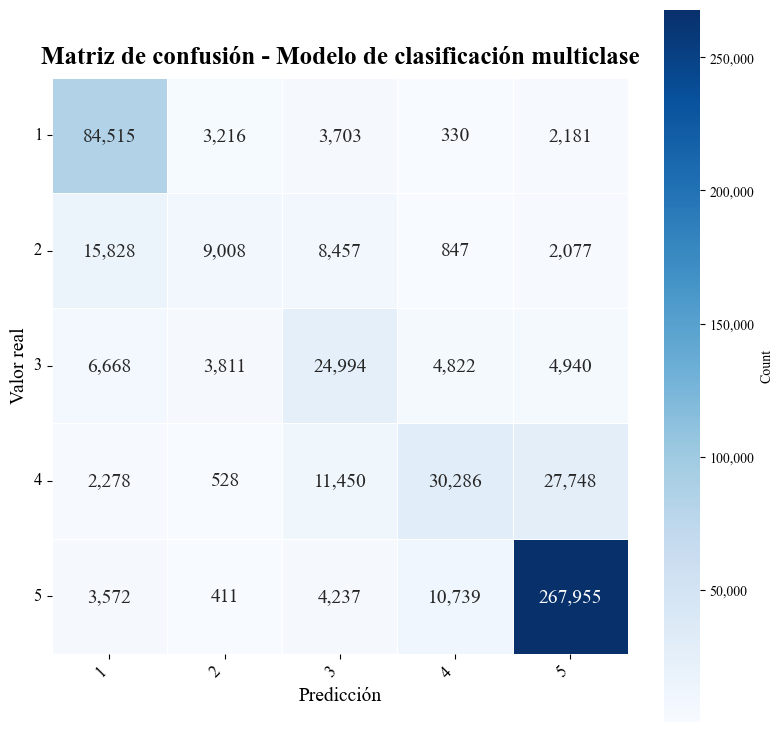

array([[ 84515,   3216,   3703,    330,   2181],
       [ 15828,   9008,   8457,    847,   2077],
       [  6668,   3811,  24994,   4822,   4940],
       [  2278,    528,  11450,  30286,  27748],
       [  3572,    411,   4237,  10739, 267955]])

In [13]:
categorical_model.plot_confusion_matrix(
    title = 'Matriz de confusión - Modelo de clasificación multiclase',
    class_names = ['1', '2', '3', '4', '5'],
    xlabel = 'Predicción',
    ylabel = 'Valor real',
    annot_fontsize = 14,
    label_fontsize = 14,
)

In [17]:
categorical_model.list_available_models()



Available Model Versions (filtered by: categorical_model)

1. Run ID: 70642454865d45c885b358c97a375133
   Run Name: categorical_model_400features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-11-16 21:20:10.362000+00:00
   End Time: 2025-11-16 21:20:52.397000+00:00
   Metrics: Loss: 0.6238, Val Loss: 0.5822, Accuracy: 0.7593, Val Accuracy: 0.7785

2. Run ID: d6ef849fd1704e4fa29276540363cf41
   Run Name: categorical_model_400features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-11-16 03:00:44.532000+00:00
   End Time: 2025-11-16 03:01:05.297000+00:00
   Metrics: Loss: 0.6881, Val Loss: 0.6559, Accuracy: 0.7333, Val Accuracy: 0.7478

3. Run ID: a37edf50ad294411a0f39cb9231ee810
   Run Name: categorical_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 18:34:57.464000+00:00
   End Time: 2025-10-19 18:35:11.320000+00:00
   Metrics: Loss: 0.9582, Val Loss: 1.1236, Accuracy: 0.6438, Val Accuracy: 0.6600



In [9]:
from src.utils.models import CategoricalModel
categorical_model = CategoricalModel(
    'categorical_model', 
    METASTORE_PATH, 
    num_classes=6,
    tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    spark_utils=spark_utils,
    target_path=src_dir_categorical,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)
categorical_model.input_shape = 400
categorical_model.create_model()
categorical_model.model.summary()
categorical_model.plot_model(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/category_model.png",
    levels = 4
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,086 (570.65 KB)

 Trainable params: 146,086 (570.65 KB)

 Non-trainable params: 0 (0.00 B)

model plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_model.png


'/mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_model.png'

In [ ]:
categorical_model.get_model_versions()


In [ ]:
categorical_model.get_latest_model_history()


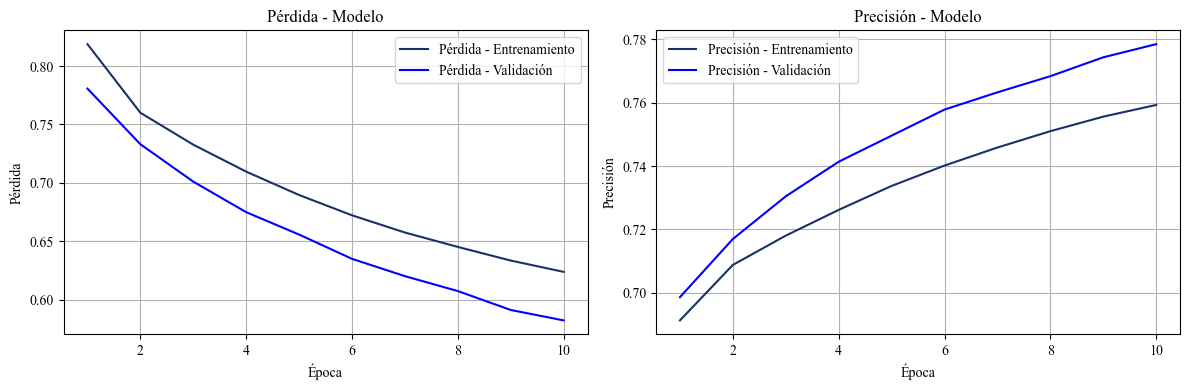

In [14]:
categorical_model.plot_latest_model_history()
